# MIMIC Target Dataset EDA

Exploratory analysis for all available MIMIC target datasets under:

- `obs24_target8_gap0`
- `obs24_target8_gap2`

The notebook expects each target folder to contain `labels.csv`, `records.csv`, and `dataset_metadata.json`.

In [1]:
from pathlib import Path
import json
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
plt.style.use("ggplot")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "mimic_targets").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data" / "mimic_targets"
SETTINGS = ["obs24_target8_gap0", "obs24_target8_gap2"]

# Set to an integer such as 1_000_000 if the full records files are too large for local memory.
RECORD_NROWS = None

DATA_ROOT

WindowsPath('c:/Users/micha/Documents/Explainable ViT for Clinical Data/data/mimic_targets')

## Load Datasets

In [2]:
def discover_target_dirs(data_root=DATA_ROOT, settings=SETTINGS):
    rows = []
    for setting in settings:
        setting_dir = data_root / setting
        if not setting_dir.exists():
            continue
        for target_dir in sorted(p for p in setting_dir.iterdir() if p.is_dir()):
            rows.append({"setting": setting, "target": target_dir.name, "path": target_dir})
    return pd.DataFrame(rows)


target_dirs = discover_target_dirs()
target_dirs

,setting,target,path
0,obs24_target8_gap0,hypoglycemia,c:\Users\micha\Documents\Explainable ViT for Clinical Data\data\mimic_targets\obs24_target8_gap0\hypoglycemia
1,obs24_target8_gap0,hypokalemia,c:\Users\micha\Documents\Explainable ViT for Clinical Data\data\mimic_targets\obs24_target8_gap0\hypokalemia
2,obs24_target8_gap0,hypotension,c:\Users\micha\Documents\Explainable ViT for Clinical Data\data\mimic_targets\obs24_target8_gap0\hypotension
3,obs24_target8_gap2,hypoglycemia,c:\Users\micha\Documents\Explainable ViT for Clinical Data\data\mimic_targets\obs24_target8_gap2\hypoglycemia
4,obs24_target8_gap2,hypokalemia,c:\Users\micha\Documents\Explainable ViT for Clinical Data\data\mimic_targets\obs24_target8_gap2\hypokalemia
5,obs24_target8_gap2,hypotension,c:\Users\micha\Documents\Explainable ViT for Clinical Data\data\mimic_targets\obs24_target8_gap2\hypotension


In [3]:
def load_one_dataset(setting, target, path, record_nrows=RECORD_NROWS):
    labels_path = path / "labels.csv"
    records_path = path / "records.csv"
    metadata_path = path / "dataset_metadata.json"

    labels = pd.read_csv(labels_path)
    records = pd.read_csv(records_path, nrows=record_nrows)
    metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}

    labels["setting"] = setting
    labels["target"] = target
    labels["label"] = labels["label"].astype(bool)

    records["setting"] = setting
    records["target"] = target
    records["value"] = pd.to_numeric(records["value"], errors="coerce")
    records["timestamp"] = pd.to_datetime(records["timestamp"], errors="coerce")

    return labels, records, metadata


labels_by_dataset = {}
records_by_dataset = {}
metadata_by_dataset = {}

for row in target_dirs.itertuples(index=False):
    key = (row.setting, row.target)
    labels_by_dataset[key], records_by_dataset[key], metadata_by_dataset[key] = load_one_dataset(
        row.setting, row.target, row.path
    )

labels = pd.concat(labels_by_dataset.values(), ignore_index=True)
records = pd.concat(records_by_dataset.values(), ignore_index=True)

labels.shape, records.shape

((448974, 4), (72272694, 6))

## Metadata And Cohort Overview

In [4]:
def metadata_summary(metadata_by_dataset):
    rows = []
    for (setting, target), metadata in metadata_by_dataset.items():
        label_counts = metadata.get("label_counts", {}) or {}
        window = metadata.get("window", {}) or {}
        rows.append(
            {
                "setting": setting,
                "target": target,
                "observation_hours": window.get("observation_hours"),
                "prediction_hours": window.get("prediction_hours"),
                "gap_hours": window.get("gap_hours"),
                "metadata_candidate_icus": metadata.get("n_candidate_icus"),
                "metadata_labeled_icus": metadata.get("n_labeled_icus"),
                "metadata_records": metadata.get("n_records"),
                "metadata_positive": label_counts.get("true", label_counts.get(True)),
                "metadata_negative": label_counts.get("false", label_counts.get(False)),
                "n_variables_metadata": len(metadata.get("record_counts_by_variable", {}) or {}),
                "target_definition": (metadata.get("target_metadata", {}) or {}).get("target_definition"),
            }
        )
    out = pd.DataFrame(rows)
    out["metadata_prevalence"] = out["metadata_positive"] / out["metadata_labeled_icus"]
    return out.sort_values(["target", "setting"])


meta_df = metadata_summary(metadata_by_dataset)
meta_df

,setting,target,observation_hours,prediction_hours,gap_hours,metadata_candidate_icus,metadata_labeled_icus,metadata_records,metadata_positive,metadata_negative,n_variables_metadata,target_definition,metadata_prevalence
0,obs24_target8_gap0,hypoglycemia,24,8,0,74829,74829,12045449,684,74145,32,Glucose < 70.0 mg/dL in prediction window,0.009141
3,obs24_target8_gap2,hypoglycemia,24,8,2,74829,74829,12045449,652,74177,32,Glucose < 70.0 mg/dL in prediction window,0.008713
1,obs24_target8_gap0,hypokalemia,24,8,0,74829,74829,12045449,5807,69022,32,Potassium < 3.6 mmol/L in prediction window,0.077604
4,obs24_target8_gap2,hypokalemia,24,8,2,74829,74829,12045449,5765,69064,32,Potassium < 3.6 mmol/L in prediction window,0.077042
2,obs24_target8_gap0,hypotension,24,8,0,74829,74829,12045449,52116,22713,32,Systolic blood pressure < 90 mmHg or diastolic blood pressure < 60 mmHg in ICU prediction window,0.696468
5,obs24_target8_gap2,hypotension,24,8,2,74829,74829,12045449,49504,25325,32,Systolic blood pressure < 90 mmHg or diastolic blood pressure < 60 mmHg in ICU prediction window,0.661562


In [5]:
loaded_summary = (
    labels.groupby(["setting", "target"])
    .agg(
        loaded_patients=("patient_id", "nunique"),
        loaded_positive=("label", "sum"),
        loaded_negative=("label", lambda s: (~s).sum()),
    )
    .reset_index()
)
record_summary = (
    records.groupby(["setting", "target"])
    .agg(
        loaded_records=("patient_id", "size"),
        patients_with_records=("patient_id", "nunique"),
        loaded_variables=("variable", "nunique"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
    )
    .reset_index()
)

cohort_df = (
    meta_df.merge(loaded_summary, on=["setting", "target"], how="left")
    .merge(record_summary, on=["setting", "target"], how="left")
)
cohort_df["loaded_prevalence"] = cohort_df["loaded_positive"] / cohort_df["loaded_patients"]
cohort_df["metadata_vs_loaded_record_ratio"] = cohort_df["loaded_records"] / cohort_df["metadata_records"]
cohort_df

,setting,target,observation_hours,prediction_hours,gap_hours,metadata_candidate_icus,metadata_labeled_icus,metadata_records,metadata_positive,metadata_negative,n_variables_metadata,target_definition,metadata_prevalence,loaded_patients,loaded_positive,loaded_negative,loaded_records,patients_with_records,loaded_variables,first_timestamp,last_timestamp,loaded_prevalence,metadata_vs_loaded_record_ratio
0,obs24_target8_gap0,hypoglycemia,24,8,0,74829,74829,12045449,684,74145,32,Glucose < 70.0 mg/dL in prediction window,0.009141,74829,684,74145,12045449,74829,32,2000-01-01,2000-01-01 23:59:59,0.009141,1.0
1,obs24_target8_gap2,hypoglycemia,24,8,2,74829,74829,12045449,652,74177,32,Glucose < 70.0 mg/dL in prediction window,0.008713,74829,652,74177,12045449,74829,32,2000-01-01,2000-01-01 23:59:59,0.008713,1.0
2,obs24_target8_gap0,hypokalemia,24,8,0,74829,74829,12045449,5807,69022,32,Potassium < 3.6 mmol/L in prediction window,0.077604,74829,5807,69022,12045449,74829,32,2000-01-01,2000-01-01 23:59:59,0.077604,1.0
3,obs24_target8_gap2,hypokalemia,24,8,2,74829,74829,12045449,5765,69064,32,Potassium < 3.6 mmol/L in prediction window,0.077042,74829,5765,69064,12045449,74829,32,2000-01-01,2000-01-01 23:59:59,0.077042,1.0
4,obs24_target8_gap0,hypotension,24,8,0,74829,74829,12045449,52116,22713,32,Systolic blood pressure < 90 mmHg or diastolic blood pressure < 60 mmHg in ICU prediction window,0.696468,74829,52116,22713,12045449,74829,32,2000-01-01,2000-01-01 23:59:59,0.696468,1.0
5,obs24_target8_gap2,hypotension,24,8,2,74829,74829,12045449,49504,25325,32,Systolic blood pressure < 90 mmHg or diastolic blood pressure < 60 mmHg in ICU prediction window,0.661562,74829,49504,25325,12045449,74829,32,2000-01-01,2000-01-01 23:59:59,0.661562,1.0


## Label Balance

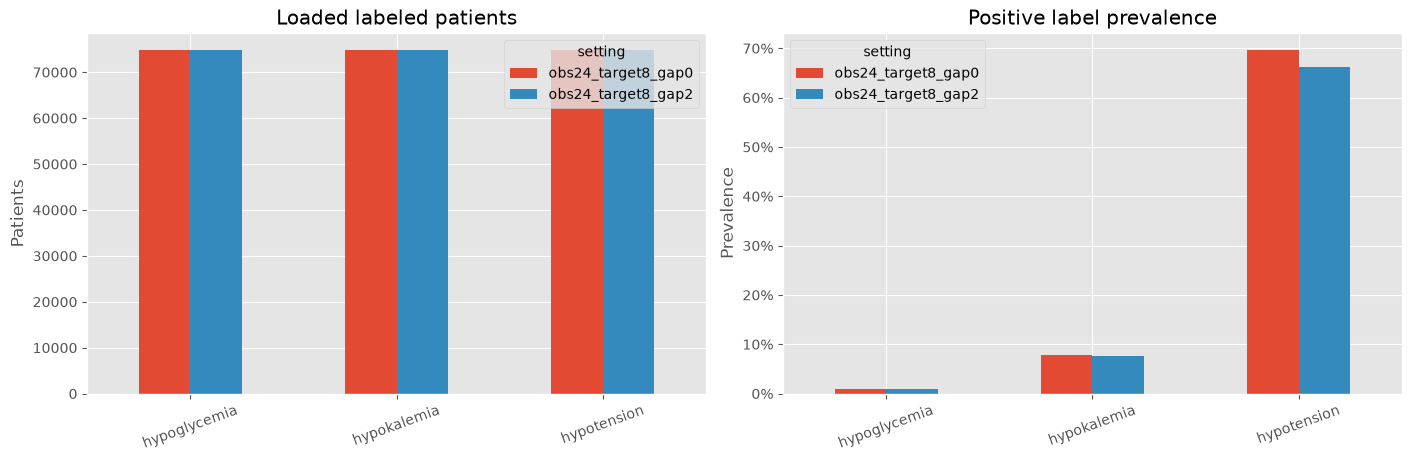

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

cohort_df.pivot(index="target", columns="setting", values="loaded_patients").plot(kind="bar", ax=axes[0])
axes[0].set_title("Loaded labeled patients")
axes[0].set_xlabel("")
axes[0].set_ylabel("Patients")
axes[0].tick_params(axis="x", rotation=20)

cohort_df.pivot(index="target", columns="setting", values="loaded_prevalence").plot(kind="bar", ax=axes[1])
axes[1].set_title("Positive label prevalence")
axes[1].set_xlabel("")
axes[1].set_ylabel("Prevalence")
axes[1].tick_params(axis="x", rotation=20)
axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.show()

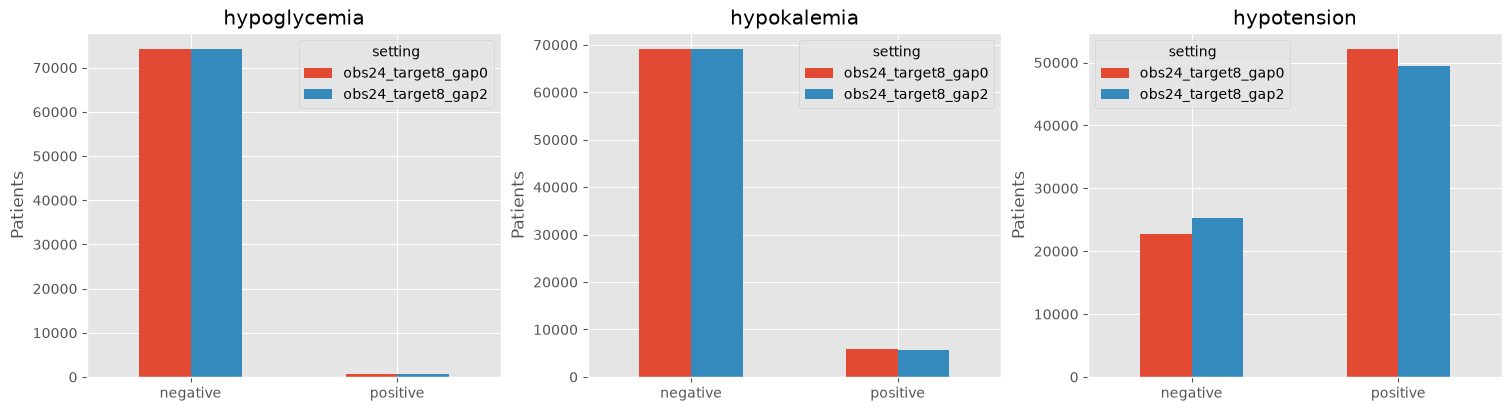

label_name                       negative  positive
target       setting                               
hypoglycemia obs24_target8_gap0   74145.0     684.0
             obs24_target8_gap2   74177.0     652.0
hypokalemia  obs24_target8_gap0   69022.0    5807.0
             obs24_target8_gap2   69064.0    5765.0
hypotension  obs24_target8_gap0   22713.0   52116.0
             obs24_target8_gap2   25325.0   49504.0

In [7]:
label_counts = (
    labels.assign(label_name=lambda d: np.where(d["label"], "positive", "negative"))
    .groupby(["setting", "target", "label_name"])
    .size()
    .rename("count")
    .reset_index()
)

targets = sorted(label_counts["target"].unique())
fig, axes = plt.subplots(1, len(targets), figsize=(5 * len(targets), 4), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, target in zip(axes, targets):
    plot_df = label_counts[label_counts["target"] == target]
    plot_df.pivot(index="label_name", columns="setting", values="count").plot(kind="bar", ax=ax)
    ax.set_title(target)
    ax.set_xlabel("")
    ax.set_ylabel("Patients")
    ax.tick_params(axis="x", rotation=0)
plt.show()

label_counts.pivot_table(index=["target", "setting"], columns="label_name", values="count", fill_value=0)

## Record And Variable Coverage

In [8]:
records_with_labels = records.merge(labels, on=["setting", "target", "patient_id"], how="left")
records_with_labels["label_name"] = np.where(records_with_labels["label"], "positive", "negative")

variable_counts = (
    records_with_labels.groupby(["setting", "target", "variable"])
    .agg(
        n_records=("value", "size"),
        n_patients=("patient_id", "nunique"),
        missing_values=("value", lambda s: s.isna().sum()),
        median_value=("value", "median"),
        q1_value=("value", lambda s: s.quantile(0.25)),
        q3_value=("value", lambda s: s.quantile(0.75)),
    )
    .reset_index()
)
variable_counts["missing_rate"] = variable_counts["missing_values"] / variable_counts["n_records"]
variable_counts.sort_values(["target", "setting", "n_records"], ascending=[True, True, False]).head(30)

,setting,target,variable,n_records,n_patients,missing_values,median_value,q1_value,q3_value,missing_rate
28,obs24_target8_gap0,hypoglycemia,systolic_bp,2157241,74717,0,114.000000,101.0,130.0,0.0
7,obs24_target8_gap0,hypoglycemia,diastolic_bp,2156741,74714,0,61.000000,52.0,71.0,0.0
9,obs24_target8_gap0,hypoglycemia,heart_rate,2096007,74752,0,84.000000,72.0,97.0,0.0
19,obs24_target8_gap0,hypoglycemia,o2_saturation_pulseox,2093513,74766,0,97.000000,95.0,99.0,0.0
29,obs24_target8_gap0,hypoglycemia,temperature,596628,72719,0,36.833333,36.5,37.2,0.0
6,obs24_target8_gap0,hypoglycemia,dextrose_maintenance,363409,48595,0,1.000000,1.0,1.0,0.0
23,obs24_target8_gap0,hypoglycemia,potassium,247443,73721,0,4.200000,3.8,4.7,0.0
1,obs24_target8_gap0,hypoglycemia,blood_glucose,241403,73655,0,133.000000,109.0,166.0,0.0
10,obs24_target8_gap0,hypoglycemia,hemoglobin,207276,73301,0,9.900000,8.5,11.4,0.0
27,obs24_target8_gap0,hypoglycemia,sodium,205205,73710,0,138.000000,135.0,141.0,0.0


### Sampling Frequency For One Target And Setting

In [9]:
# Choose any available dataset pair, for example:
# SELECTED_SETTING = "obs24_target8_gap0"
# SELECTED_TARGET = "hypotension"
SELECTED_SETTING = "obs24_target8_gap0"
SELECTED_TARGET = "hypotension"

selected_key = (SELECTED_SETTING, SELECTED_TARGET)
if selected_key not in records_by_dataset:
    selected_key = next(iter(records_by_dataset))
    SELECTED_SETTING, SELECTED_TARGET = selected_key
    print(f"Selected pair was not found. Using {SELECTED_SETTING}/{SELECTED_TARGET} instead.")

selected_records = records_by_dataset[selected_key].copy()
selected_labels = labels_by_dataset[selected_key].copy()
selected_metadata = metadata_by_dataset.get(selected_key, {})
observation_hours = (selected_metadata.get("window", {}) or {}).get("observation_hours")

if observation_hours is None:
    observation_hours = (
        selected_records["timestamp"].max() - selected_records["timestamp"].min()
    ).total_seconds() / 3600

n_labeled_stays = selected_labels["patient_id"].nunique()

samples_per_observed_stay = (
    selected_records.groupby(["variable", "patient_id"])
    .agg(
        n_samples=("value", "size"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
    )
    .reset_index()
)
samples_per_observed_stay["observed_span_hours"] = (
    samples_per_observed_stay["last_timestamp"] - samples_per_observed_stay["first_timestamp"]
).dt.total_seconds() / 3600
samples_per_observed_stay["hours_between_measurements"] = np.where(
    samples_per_observed_stay["n_samples"] > 1,
    samples_per_observed_stay["observed_span_hours"] / (samples_per_observed_stay["n_samples"] - 1),
    np.nan,
)
samples_per_observed_stay["measurements_per_hour"] = samples_per_observed_stay["n_samples"] / observation_hours

variable_sampling_summary = (
    samples_per_observed_stay.groupby("variable")
    .agg(
        stays_with_variable=("patient_id", "nunique"),
        total_samples=("n_samples", "sum"),
        mean_samples_per_observed_stay=("n_samples", "mean"),
        median_samples_per_observed_stay=("n_samples", "median"),
        p90_samples_per_observed_stay=("n_samples", lambda s: s.quantile(0.9)),
        mean_measurements_per_hour_when_observed=("measurements_per_hour", "mean"),
        mean_hours_between_measurements=("hours_between_measurements", "mean"),
    )
    .reset_index()
)
variable_sampling_summary["total_labeled_stays"] = n_labeled_stays
variable_sampling_summary["stay_coverage"] = variable_sampling_summary["stays_with_variable"] / n_labeled_stays
variable_sampling_summary["mean_samples_per_labeled_stay"] = (
    variable_sampling_summary["total_samples"] / n_labeled_stays
)
variable_sampling_summary["mean_measurements_per_hour_per_labeled_stay"] = (
    variable_sampling_summary["mean_samples_per_labeled_stay"] / observation_hours
)

ordered_columns = [
    "variable",
    "total_labeled_stays",
    "stays_with_variable",
    "stay_coverage",
    "total_samples",
    "mean_samples_per_labeled_stay",
    "mean_samples_per_observed_stay",
    "median_samples_per_observed_stay",
    "p90_samples_per_observed_stay",
    "mean_measurements_per_hour_per_labeled_stay",
    "mean_measurements_per_hour_when_observed",
    "mean_hours_between_measurements",
]

print(
    f"Sampling summary for {SELECTED_SETTING}/{SELECTED_TARGET} "
    f"over a {observation_hours:g}-hour observation window"
)
variable_sampling_summary[ordered_columns].sort_values(
    "mean_samples_per_labeled_stay", ascending=False
).reset_index(drop=True)


Sampling summary for obs24_target8_gap0/hypotension over a 24-hour observation window


,variable,total_labeled_stays,stays_with_variable,stay_coverage,total_samples,mean_samples_per_labeled_stay,mean_samples_per_observed_stay,median_samples_per_observed_stay,p90_samples_per_observed_stay,mean_measurements_per_hour_per_labeled_stay,mean_measurements_per_hour_when_observed,mean_hours_between_measurements
0,systolic_bp,74829,74717,0.998503,2157241,28.828943,28.872158,25.0,41.0,1.201206,1.203007,0.885870
1,diastolic_bp,74829,74714,0.998463,2156741,28.822261,28.866625,25.0,41.0,1.200928,1.202776,0.886005
2,heart_rate,74829,74752,0.998971,2096007,28.010624,28.039477,26.0,36.0,1.167109,1.168312,0.876190
3,o2_saturation_pulseox,74829,74766,0.999158,2093513,27.977295,28.000869,26.0,36.0,1.165721,1.166703,0.882977
4,temperature,74829,72719,0.971802,596628,7.973219,8.204568,7.0,13.0,0.332217,0.341857,3.466268
5,dextrose_maintenance,74829,48595,0.649414,363409,4.856526,7.478321,5.0,18.0,0.202355,0.311597,4.087890
6,potassium,74829,73721,0.985193,247443,3.306779,3.356479,2.0,8.0,0.137782,0.139853,7.294260
7,blood_glucose,74829,73655,0.984311,241403,3.226062,3.277483,2.0,7.0,0.134419,0.136562,7.357673
8,hemoglobin,74829,73301,0.979580,207276,2.769996,2.827738,2.0,6.0,0.115416,0.117822,7.641056
9,sodium,74829,73710,0.985046,205205,2.742319,2.783951,2.0,5.0,0.114263,0.115998,7.921843


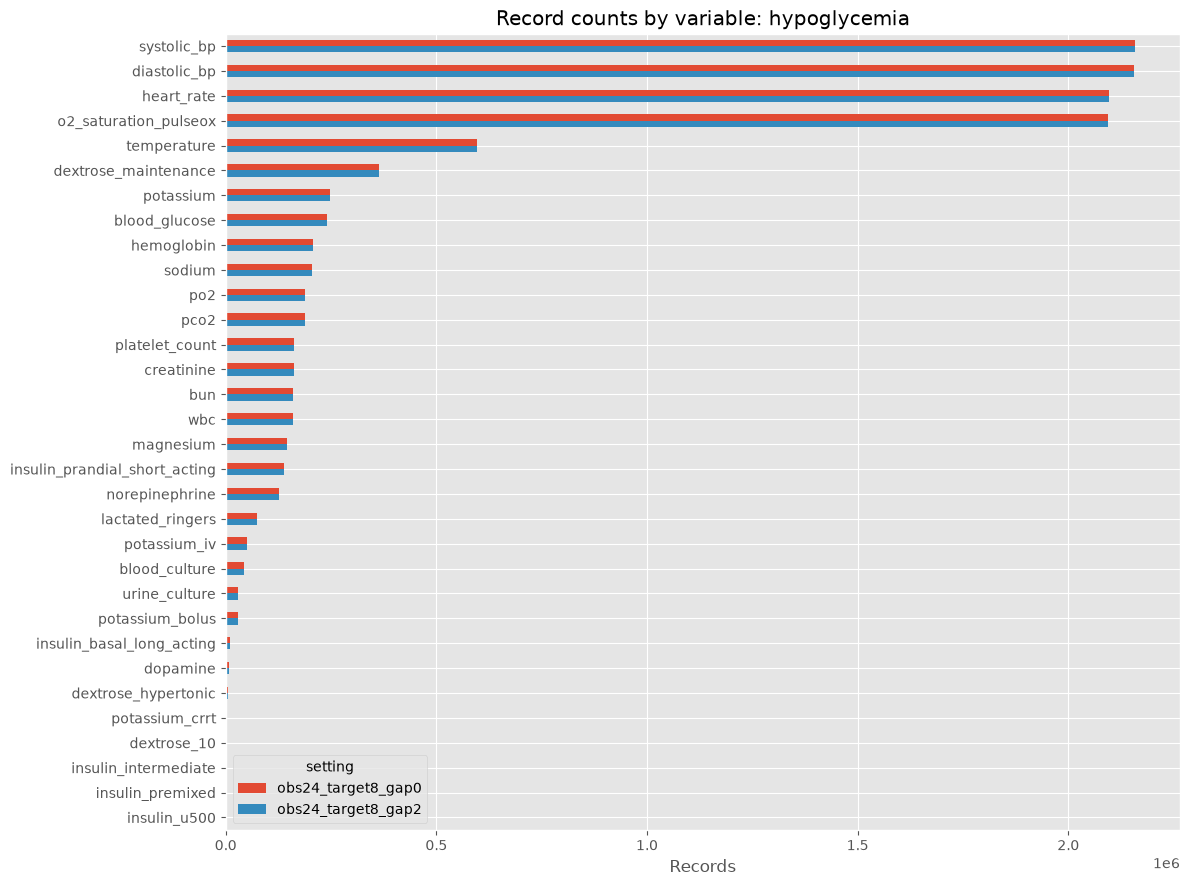

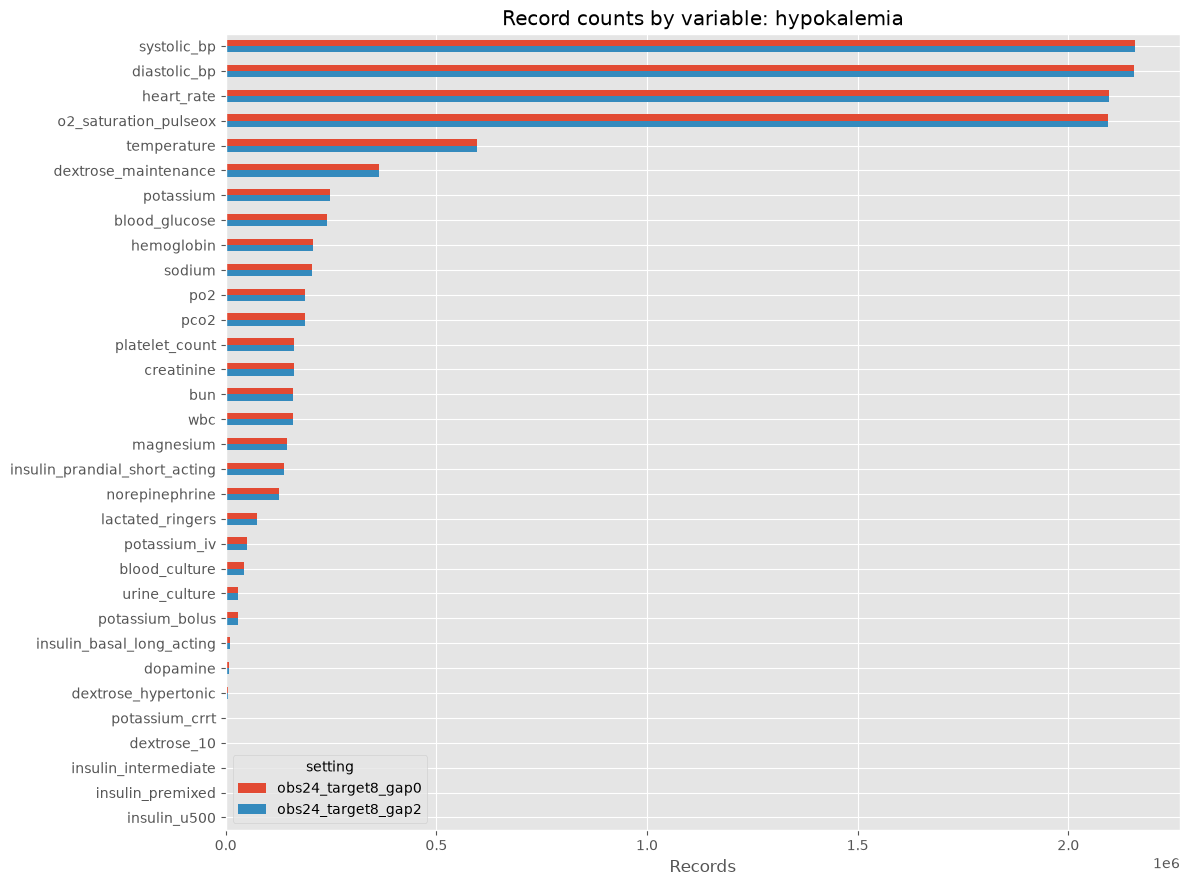

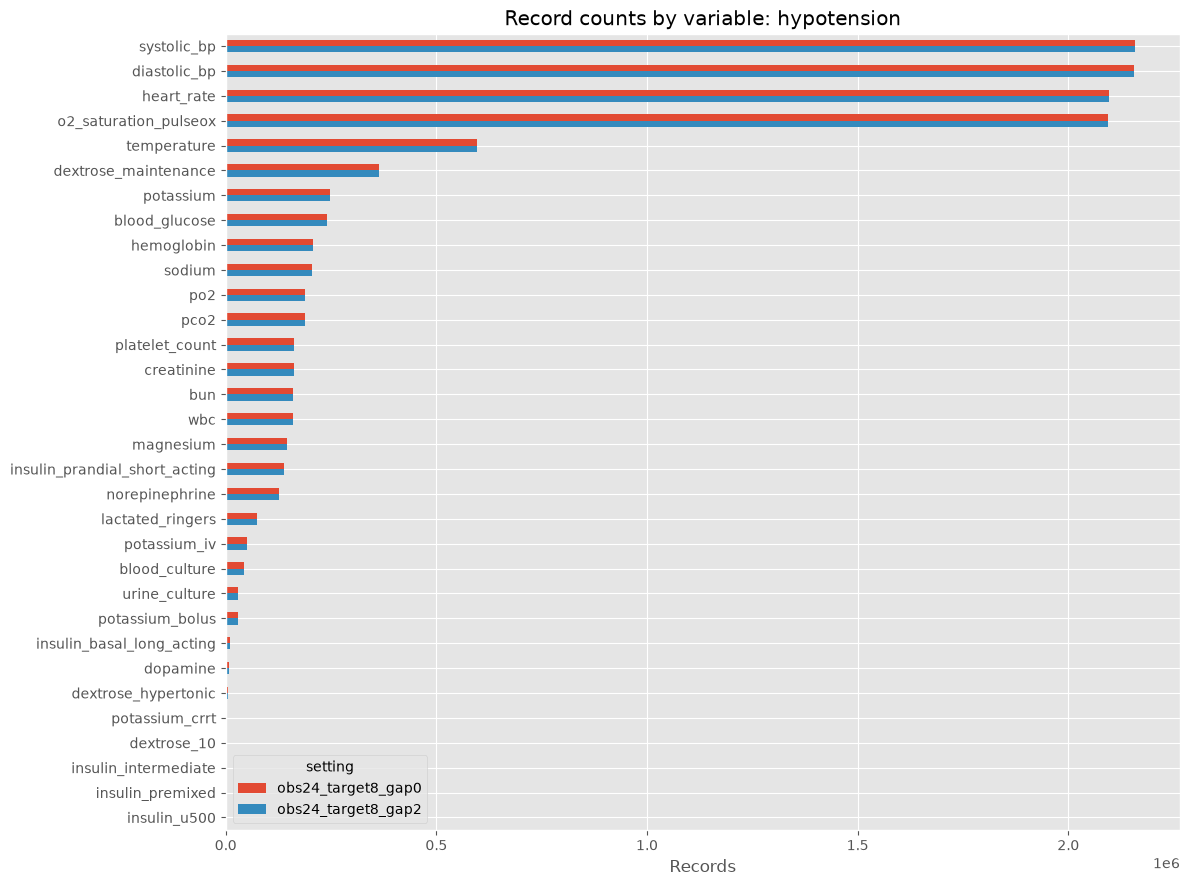

In [10]:
for target in sorted(records["target"].unique()):
    plot_df = variable_counts[variable_counts["target"] == target].sort_values("n_records", ascending=False)
    order = plot_df.groupby("variable")["n_records"].sum().sort_values(ascending=False).index
    ax = (
        plot_df.pivot(index="variable", columns="setting", values="n_records")
        .reindex(order)
        .plot(kind="barh", figsize=(12, max(4, 0.28 * len(order))))
    )
    ax.invert_yaxis()
    ax.set_title(f"Record counts by variable: {target}")
    ax.set_xlabel("Records")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

In [11]:
patient_coverage = (
    records_with_labels.groupby(["setting", "target", "label_name", "patient_id"])
    .agg(
        n_records=("value", "size"),
        n_variables=("variable", "nunique"),
    )
    .reset_index()
)

coverage_summary = (
    patient_coverage.groupby(["setting", "target", "label_name"])
    .agg(
        patients=("patient_id", "nunique"),
        median_records_per_patient=("n_records", "median"),
        p90_records_per_patient=("n_records", lambda s: s.quantile(0.9)),
        median_variables_per_patient=("n_variables", "median"),
        p90_variables_per_patient=("n_variables", lambda s: s.quantile(0.9)),
    )
    .reset_index()
)
coverage_summary

,setting,target,label_name,patients,median_records_per_patient,p90_records_per_patient,median_variables_per_patient,p90_variables_per_patient
0,obs24_target8_gap0,hypoglycemia,negative,74145,145.0,232.0,17.0,21.0
1,obs24_target8_gap0,hypoglycemia,positive,684,161.0,273.7,19.0,22.0
2,obs24_target8_gap0,hypokalemia,negative,69022,145.0,233.0,17.0,21.0
3,obs24_target8_gap0,hypokalemia,positive,5807,149.0,230.0,18.0,21.0
4,obs24_target8_gap0,hypotension,negative,22713,131.0,195.0,16.0,20.0
5,obs24_target8_gap0,hypotension,positive,52116,154.0,245.0,18.0,21.0
6,obs24_target8_gap2,hypoglycemia,negative,74177,145.0,232.0,17.0,21.0
7,obs24_target8_gap2,hypoglycemia,positive,652,159.0,276.9,19.0,22.0
8,obs24_target8_gap2,hypokalemia,negative,69064,145.0,233.0,17.0,21.0
9,obs24_target8_gap2,hypokalemia,positive,5765,149.0,232.0,18.0,21.0


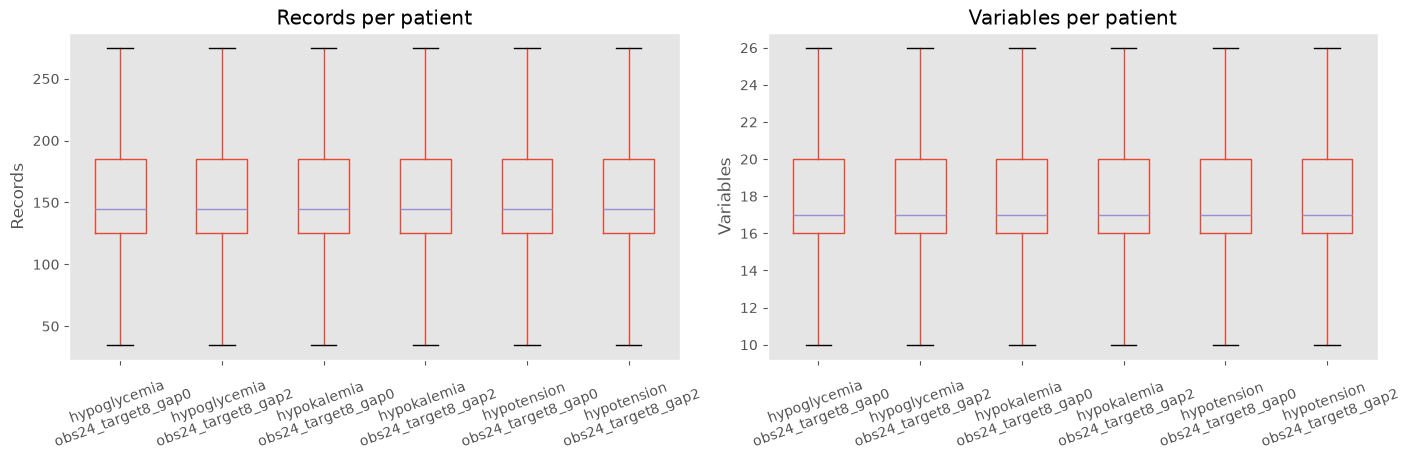

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
patient_coverage.assign(group=lambda d: d["target"] + "\n" + d["setting"]).boxplot(
    column="n_records", by="group", showfliers=False, ax=axes[0], grid=False
)
axes[0].set_title("Records per patient")
axes[0].set_xlabel("")
axes[0].set_ylabel("Records")
axes[0].tick_params(axis="x", rotation=20)

patient_coverage.assign(group=lambda d: d["target"] + "\n" + d["setting"]).boxplot(
    column="n_variables", by="group", showfliers=False, ax=axes[1], grid=False
)
axes[1].set_title("Variables per patient")
axes[1].set_xlabel("")
axes[1].set_ylabel("Variables")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle("")
plt.show()

## Time Coverage

In [13]:
records_with_labels["hours_since_anchor"] = (
    records_with_labels["timestamp"] - pd.Timestamp("2000-01-01 00:00:00")
).dt.total_seconds() / 3600

time_summary = (
    records_with_labels.groupby(["setting", "target"])
    .agg(
        min_hour=("hours_since_anchor", "min"),
        q1_hour=("hours_since_anchor", lambda s: s.quantile(0.25)),
        median_hour=("hours_since_anchor", "median"),
        q3_hour=("hours_since_anchor", lambda s: s.quantile(0.75)),
        max_hour=("hours_since_anchor", "max"),
    )
    .reset_index()
)
time_summary

,setting,target,min_hour,q1_hour,median_hour,q3_hour,max_hour
0,obs24_target8_gap0,hypoglycemia,0.0,4.659167,10.433056,16.953889,23.999722
1,obs24_target8_gap0,hypokalemia,0.0,4.659167,10.433056,16.953889,23.999722
2,obs24_target8_gap0,hypotension,0.0,4.659167,10.433056,16.953889,23.999722
3,obs24_target8_gap2,hypoglycemia,0.0,4.659167,10.433056,16.953889,23.999722
4,obs24_target8_gap2,hypokalemia,0.0,4.659167,10.433056,16.953889,23.999722
5,obs24_target8_gap2,hypotension,0.0,4.659167,10.433056,16.953889,23.999722


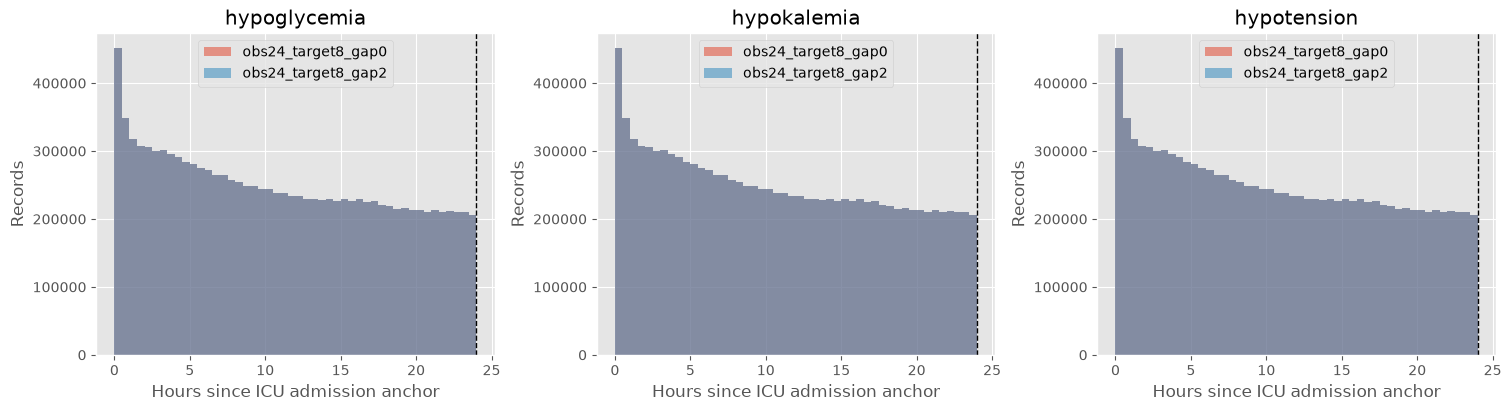

In [14]:
targets = sorted(records_with_labels["target"].unique())
fig, axes = plt.subplots(1, len(targets), figsize=(5 * len(targets), 4), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, target in zip(axes, targets):
    for setting, group in records_with_labels[records_with_labels["target"] == target].groupby("setting"):
        ax.hist(group["hours_since_anchor"].dropna(), bins=48, alpha=0.55, label=setting)
    ax.axvline(24, color="black", linestyle="--", linewidth=1)
    ax.set_title(target)
    ax.set_xlabel("Hours since ICU admission anchor")
    ax.set_ylabel("Records")
    ax.legend()
plt.show()

## Value Distributions

In [15]:
value_summary = (
    records_with_labels.groupby(["setting", "target", "variable"])["value"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)
value_summary.sort_values(["target", "setting", "count"], ascending=[True, True, False]).head(40)

,setting,target,variable,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
28,obs24_target8_gap0,hypoglycemia,systolic_bp,2157241.0,117.521772,708.614551,-94.00,73.000000,86.0,101.0,114.000000,130.0,157.000000,178.000000,1025100.0
7,obs24_target8_gap0,hypoglycemia,diastolic_bp,2156741.0,63.927065,278.887843,-40.00,34.000000,42.0,52.0,61.000000,71.0,90.000000,108.000000,114109.0
9,obs24_target8_gap0,hypoglycemia,heart_rate,2096007.0,85.483452,19.816090,0.00,49.000000,58.0,72.0,84.000000,97.0,119.000000,137.000000,6262.0
19,obs24_target8_gap0,hypoglycemia,o2_saturation_pulseox,2093513.0,104.212128,6922.091191,-8.00,88.000000,92.0,95.0,97.000000,99.0,100.000000,100.000000,9765430.0
29,obs24_target8_gap0,hypoglycemia,temperature,596628.0,36.851734,0.734254,26.10,34.722222,35.7,36.5,36.833333,37.2,38.055556,38.944444,42.5
6,obs24_target8_gap0,hypoglycemia,dextrose_maintenance,363409.0,1.000000,0.000000,1.00,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.000000,1.0
23,obs24_target8_gap0,hypoglycemia,potassium,247443.0,4.286004,1.029940,0.70,2.800000,3.3,3.8,4.200000,4.7,5.600000,6.600000,303.0
1,obs24_target8_gap0,hypoglycemia,blood_glucose,241403.0,153.176431,2597.947385,0.12,64.000000,83.0,109.0,133.000000,166.0,262.000000,403.980000,1276103.0
10,obs24_target8_gap0,hypoglycemia,hemoglobin,207276.0,10.079824,2.117011,0.00,6.100000,7.0,8.5,9.900000,11.4,13.800000,15.500000,97.0
27,obs24_target8_gap0,hypoglycemia,sodium,205205.0,137.472029,6.644990,1.36,117.000000,127.0,135.0,138.000000,141.0,146.000000,155.000000,1036.0


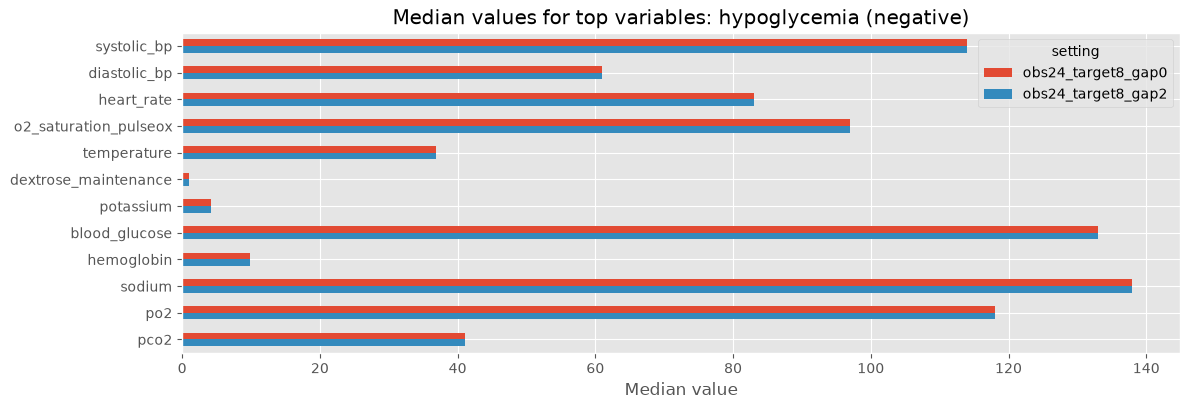

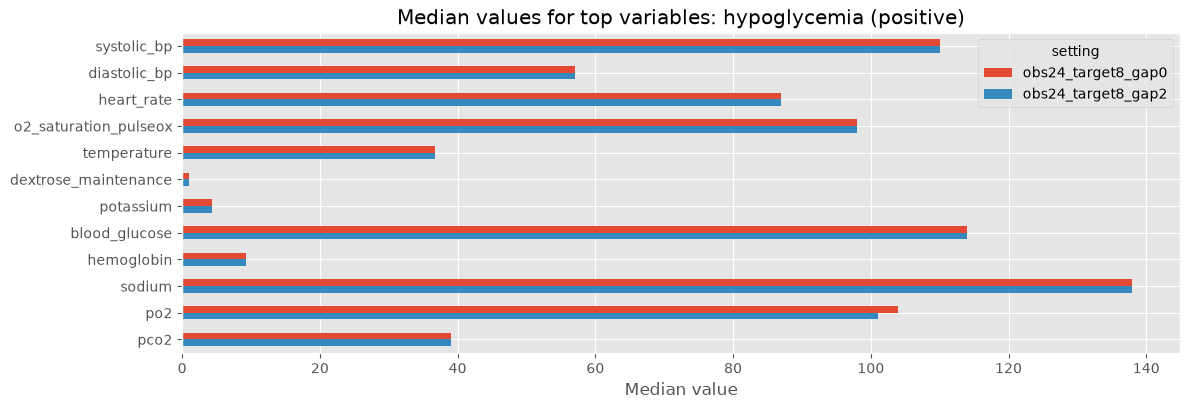

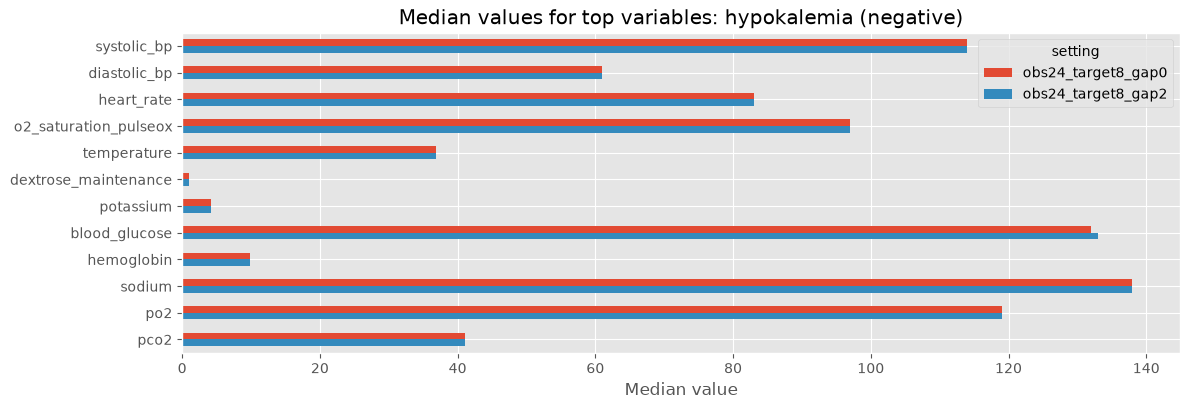

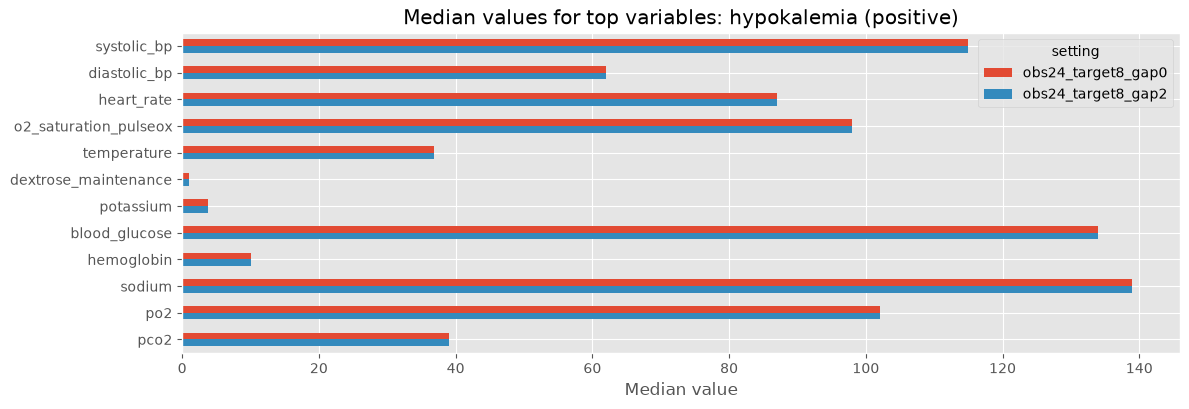

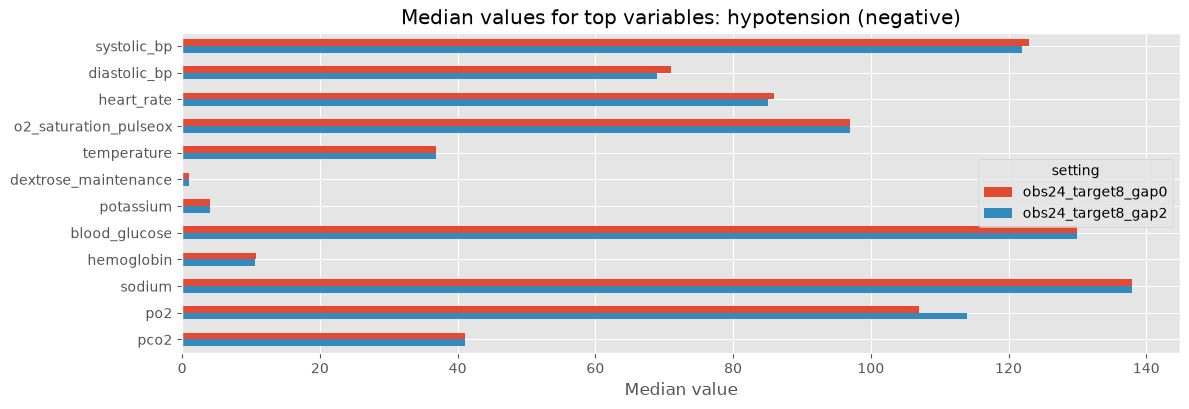

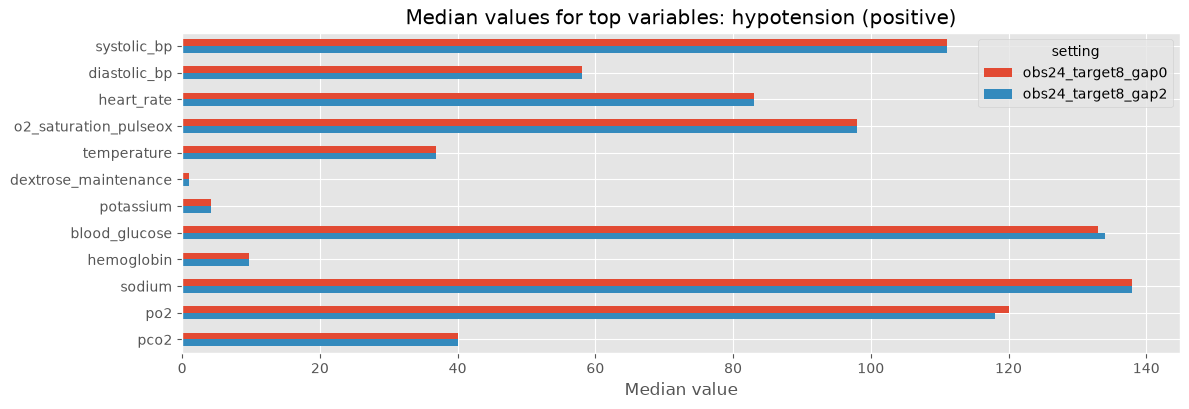

In [16]:
TOP_N_VARIABLES = 12

for target in sorted(records_with_labels["target"].unique()):
    top_vars = (
        records_with_labels.loc[records_with_labels["target"] == target, "variable"]
        .value_counts()
        .head(TOP_N_VARIABLES)
        .index
    )
    plot_df = records_with_labels[
        (records_with_labels["target"] == target) & records_with_labels["variable"].isin(top_vars)
    ].copy()
    plot_df["variable"] = pd.Categorical(plot_df["variable"], categories=top_vars, ordered=True)

    summary_plot = (
        plot_df.groupby(["variable", "setting", "label_name"])["value"]
        .median()
        .rename("median_value")
        .reset_index()
    )
    for label_name in sorted(summary_plot["label_name"].dropna().unique()):
        ax = (
            summary_plot[summary_plot["label_name"] == label_name]
            .pivot(index="variable", columns="setting", values="median_value")
            .reindex(top_vars)
            .plot(kind="barh", figsize=(12, max(4, 0.35 * len(top_vars))))
        )
        ax.invert_yaxis()
        ax.set_title(f"Median values for top variables: {target} ({label_name})")
        ax.set_xlabel("Median value")
        ax.set_ylabel("")
        plt.tight_layout()
        plt.show()

## Gap0 vs Gap2 Comparison

In [17]:
comparison_metrics = [
    "loaded_patients",
    "loaded_positive",
    "loaded_prevalence",
    "loaded_records",
    "patients_with_records",
    "loaded_variables",
]

gap_comparison = cohort_df.pivot(index="target", columns="setting", values=comparison_metrics)
gap_comparison

loaded_patients                       loaded_positive  \
setting      obs24_target8_gap0 obs24_target8_gap2 obs24_target8_gap0   
target                                                                  
hypoglycemia            74829.0            74829.0              684.0   
hypokalemia             74829.0            74829.0             5807.0   
hypotension             74829.0            74829.0            52116.0   

                                 loaded_prevalence                     \
setting      obs24_target8_gap2 obs24_target8_gap0 obs24_target8_gap2   
target                                                                  
hypoglycemia              652.0           0.009141           0.008713   
hypokalemia              5765.0           0.077604           0.077042   
hypotension             49504.0           0.696468           0.661562   

                 loaded_records                    patients_with_records  \
setting      obs24_target8_gap0 obs24_target8_gap2    obs24_target8_gap0   
target                                                                     
hypoglycemia         12045449.0         12045449.0               74829.0   
hypokalemia          12045449.0         12045449.0               74829.0   
hypotension          12045449.0         12045449.0               74829.0   

                                  loaded_variables                     
setting      obs24_target8_gap2 obs24_target8_gap0 obs24_target8_gap2  
target                                                                 
hypoglycemia            74829.0               32.0               32.0  
hypokalemia             74829.0               32.0               32.0  
hypotension             74829.0               32.0               32.0

In [18]:
delta_rows = []
for target, group in cohort_df.groupby("target"):
    by_setting = group.set_index("setting")
    if set(SETTINGS).issubset(by_setting.index):
        row = {"target": target}
        for metric in comparison_metrics:
            gap0 = by_setting.loc["obs24_target8_gap0", metric]
            gap2 = by_setting.loc["obs24_target8_gap2", metric]
            row[f"{metric}_gap2_minus_gap0"] = gap2 - gap0
            row[f"{metric}_gap2_over_gap0"] = gap2 / gap0 if gap0 else np.nan
        delta_rows.append(row)

gap_delta = pd.DataFrame(delta_rows)
gap_delta

,target,loaded_patients_gap2_minus_gap0,loaded_patients_gap2_over_gap0,loaded_positive_gap2_minus_gap0,loaded_positive_gap2_over_gap0,loaded_prevalence_gap2_minus_gap0,loaded_prevalence_gap2_over_gap0,loaded_records_gap2_minus_gap0,loaded_records_gap2_over_gap0,patients_with_records_gap2_minus_gap0,patients_with_records_gap2_over_gap0,loaded_variables_gap2_minus_gap0,loaded_variables_gap2_over_gap0
0,hypoglycemia,0,1.0,-32,0.953216,-0.000428,0.953216,0,1.0,0,1.0,0,1.0
1,hypokalemia,0,1.0,-42,0.992767,-0.000561,0.992767,0,1.0,0,1.0,0,1.0
2,hypotension,0,1.0,-2612,0.949881,-0.034906,0.949881,0,1.0,0,1.0,0,1.0


## Data Quality Checks

In [19]:
quality_rows = []
for (setting, target), dataset_labels in labels_by_dataset.items():
    dataset_records = records_by_dataset[(setting, target)]
    label_patients = set(dataset_labels["patient_id"])
    record_patients = set(dataset_records["patient_id"])
    duplicated_labels = dataset_labels.duplicated("patient_id").sum()
    quality_rows.append(
        {
            "setting": setting,
            "target": target,
            "duplicated_label_patient_rows": duplicated_labels,
            "records_with_missing_patient_id": dataset_records["patient_id"].isna().sum(),
            "records_with_missing_variable": dataset_records["variable"].isna().sum(),
            "records_with_missing_timestamp": dataset_records["timestamp"].isna().sum(),
            "records_with_missing_value": dataset_records["value"].isna().sum(),
            "patients_in_labels_not_records": len(label_patients - record_patients),
            "patients_in_records_not_labels": len(record_patients - label_patients),
        }
    )

quality_df = pd.DataFrame(quality_rows).sort_values(["target", "setting"])
quality_df

,setting,target,duplicated_label_patient_rows,records_with_missing_patient_id,records_with_missing_variable,records_with_missing_timestamp,records_with_missing_value,patients_in_labels_not_records,patients_in_records_not_labels
0,obs24_target8_gap0,hypoglycemia,0,0,0,0,0,0,0
3,obs24_target8_gap2,hypoglycemia,0,0,0,0,0,0,0
1,obs24_target8_gap0,hypokalemia,0,0,0,0,0,0,0
4,obs24_target8_gap2,hypokalemia,0,0,0,0,0,0,0
2,obs24_target8_gap0,hypotension,0,0,0,0,0,0,0
5,obs24_target8_gap2,hypotension,0,0,0,0,0,0,0


## Export Summary Tables

In [20]:
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "eda_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cohort_df.to_csv(OUTPUT_DIR / "mimic_target_cohort_summary.csv", index=False)
variable_counts.to_csv(OUTPUT_DIR / "mimic_target_variable_summary.csv", index=False)
coverage_summary.to_csv(OUTPUT_DIR / "mimic_target_patient_coverage_summary.csv", index=False)
time_summary.to_csv(OUTPUT_DIR / "mimic_target_time_summary.csv", index=False)
value_summary.to_csv(OUTPUT_DIR / "mimic_target_value_summary.csv", index=False)
quality_df.to_csv(OUTPUT_DIR / "mimic_target_quality_checks.csv", index=False)
gap_delta.to_csv(OUTPUT_DIR / "mimic_target_gap_delta_summary.csv", index=False)

sorted(p.name for p in OUTPUT_DIR.glob("*.csv"))

['mimic_target_cohort_summary.csv',
 'mimic_target_gap_delta_summary.csv',
 'mimic_target_patient_coverage_summary.csv',
 'mimic_target_quality_checks.csv',
 'mimic_target_time_summary.csv',
 'mimic_target_value_summary.csv',
 'mimic_target_variable_summary.csv']